In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/Users/nifal/Documents/Walmart_Sales.csv")

In [46]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [47]:
df.shape

(6435, 8)

In [48]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [49]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [50]:
df.columns=df.columns.str.lower()
df.columns

Index(['store', 'date', 'weekly_sales', 'holiday_flag', 'temperature',
       'fuel_price', 'cpi', 'unemployment'],
      dtype='object')

In [51]:
df['date']=pd.to_datetime(df['date'],format='%d-%m-%Y')


In [52]:
df.dtypes

store                    int64
date            datetime64[ns]
weekly_sales           float64
holiday_flag             int64
temperature            float64
fuel_price             float64
cpi                    float64
unemployment           float64
dtype: object

In [53]:
df['date'].min(),df['date'].max()

(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

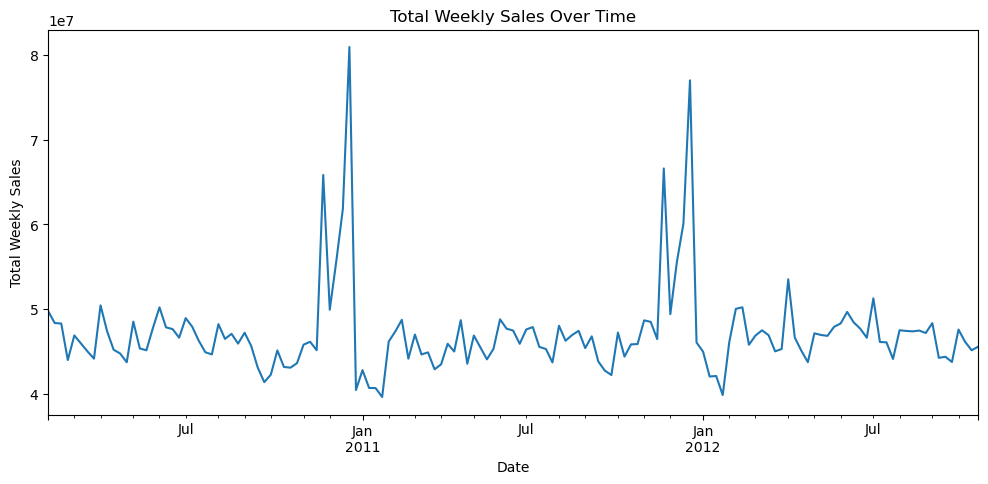

In [54]:
trend=df.groupby('date')['weekly_sales'].sum()
trend.plot(figsize=(12,5), title='Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

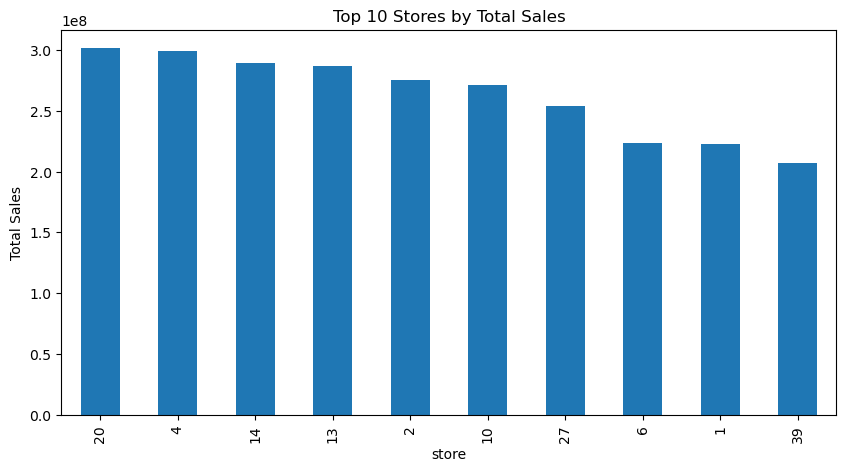

In [55]:
store_sales=df.groupby('store')['weekly_sales'].sum().sort_values(ascending=False)
store_sales.head(10).plot(kind='bar', figsize=(10,5), title="Top 10 Stores by Total Sales")
plt.xlabel('store')
plt.ylabel('Total Sales')
plt.show

In [56]:
holiday_avg=df.groupby('holiday_flag')['weekly_sales'].mean()
print(holiday_avg)

holiday_flag
0    1.041256e+06
1    1.122888e+06
Name: weekly_sales, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

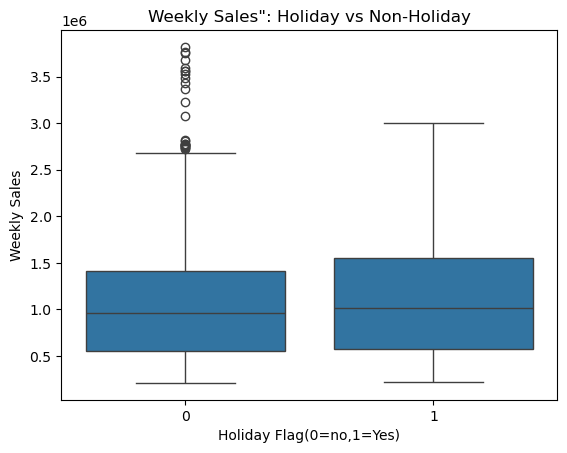

In [58]:
sns.boxplot(x='holiday_flag',y='weekly_sales',data=df)
plt.title('Weekly Sales": Holiday vs Non-Holiday')
plt.xlabel('Holiday Flag(0=no,1=Yes)')
plt.ylabel('Weekly Sales')
plt.show

In [65]:
corr=df[['weekly_sales','temperature','fuel_price','cpi','unemployment']].corr()
print(corr['weekly_sales'])

weekly_sales    1.000000
temperature    -0.063810
fuel_price      0.009464
cpi            -0.072634
unemployment   -0.106176
Name: weekly_sales, dtype: float64


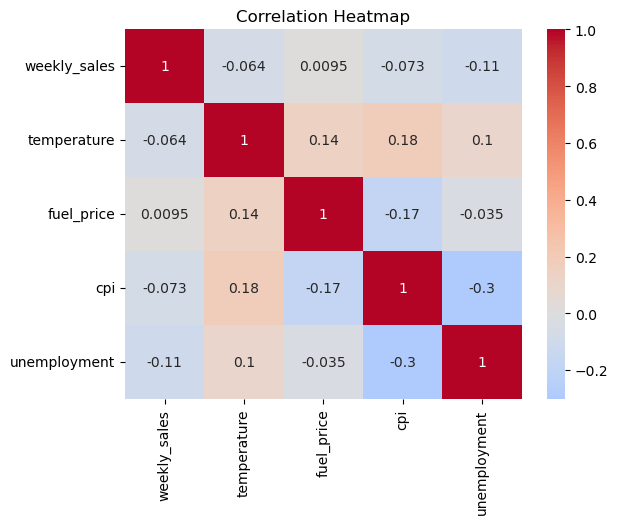

In [67]:
sns.heatmap(corr,annot=True,cmap='coolwarm',center=0)
plt.title('Correlation Heatmap')
plt.show()

In [68]:
df.to_csv('walmart_sales_cleaned.csv', index=False)